# Customer Segmentation & Retention Strategy

Name: Nirjhari Joshi

Student ID: IITP_AIML_2506082

Objective: Segment customers using RFM metrics and develop targeted retention strategies.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

zip_path = "d2c churn data package-20260615T085556Z-3-001.zip"

z = zipfile.ZipFile(zip_path)

snapshot = pd.read_csv(
    z.open('d2c churn data package/rfm_modeling_snapshot.csv')
)

snapshot.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [3]:
import os
os.listdir()

['.config', 'd2c churn data package-20260615T085556Z-3-001.zip', 'sample_data']

In [4]:
import os

print(os.getcwd())
print(os.path.exists("d2c churn data package-20260615T085556Z-3-001.zip"))

/content
True


In [5]:
import pandas as pd
import zipfile

z = zipfile.ZipFile(
    "d2c churn data package-20260615T085556Z-3-001.zip"
)

snapshot = pd.read_csv(
    z.open(
        "d2c churn data package/rfm_modeling_snapshot.csv"
    )
)

print(snapshot.shape)
snapshot.head()

(2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [7]:
snapshot['R_score'] = pd.qcut(
    snapshot['recency_days'],
    q=4,
    labels=[4,3,2,1],
    duplicates='drop'
)

snapshot['F_score'] = pd.qcut(
    snapshot['frequency_180d'],
    q=4,
    labels=False,
    duplicates='drop'
) + 1

snapshot['M_score'] = pd.qcut(
    snapshot['monetary_180d'],
    q=4,
    labels=[1,2,3,4],
    duplicates='drop'
)

snapshot['RFM_Score'] = (
    snapshot['R_score'].astype(str) +
    snapshot['F_score'].astype(str) +
    snapshot['M_score'].astype(str)
)

snapshot[['R_score','F_score','M_score','RFM_Score']].head()

,R_score,F_score,M_score,RFM_Score
0,2,1,1,211
1,3,1,2,312
2,1,1,2,112
3,1,1,3,113
4,3,3,4,334


In [8]:
def segment_customer(row):

    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 3 and m >= 3:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 3 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Hibernating"

snapshot['segment'] = snapshot.apply(
    segment_customer,
    axis=1
)

snapshot['segment'].value_counts()

,count
segment,
Hibernating,1080
Potential Loyalists,876
Champions,171
Loyal Customers,164
At Risk,109


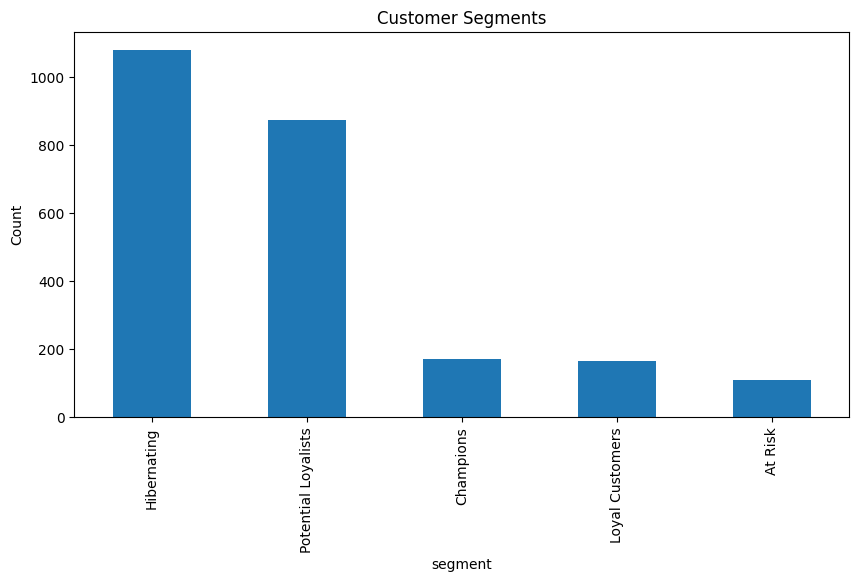

In [9]:
plt.figure(figsize=(10,5))

snapshot['segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segments')
plt.ylabel('Count')
plt.show()

In [10]:
segment_churn = snapshot.groupby(
    'segment'
)['churn_next_60d'].mean().sort_values(
    ascending=False
)

segment_churn

,churn_next_60d
segment,
Hibernating,0.779630
At Risk,0.357798
Potential Loyalists,0.243151
Loyal Customers,0.176829
Champions,0.023392


## Segment-Level Churn Analysis

The segmentation exercise reveals significant differences in churn risk across customer groups.

### Segment Performance

| Segment | Churn Rate |
|----------|------------|
| Hibernating | 77.96% |
| At Risk | 35.78% |
| Potential Loyalists | 24.32% |
| Loyal Customers | 17.68% |
| Champions | 2.34% |

### Key Insights

#### Hibernating Customers
This segment exhibits the highest churn rate (77.96%). These customers have low engagement, low purchasing activity, and are at immediate risk of leaving.

#### At Risk Customers
At Risk customers show a churn rate of 35.78%. These customers were previously valuable but have recently reduced their engagement.

#### Potential Loyalists
Potential Loyalists have moderate churn risk (24.32%) and represent a strong growth opportunity.

#### Loyal Customers
Loyal Customers demonstrate strong retention behavior, with a churn rate of only 17.68%.

#### Champions
Champions are the most valuable customer group and have the lowest churn rate at 2.34%.

### Business Conclusion

The analysis confirms that customer inactivity and declining engagement are strongly associated with churn. Retention efforts should primarily focus on Hibernating and At Risk customers while maintaining engagement among Champions and Loyal Customers.

## Retention Strategy Recommendations

| Segment | Recommended Action |
|----------|-------------------|
| Champions | VIP rewards, exclusive launches, referral incentives |
| Loyal Customers | Loyalty points, personalized recommendations |
| Potential Loyalists | Upsell campaigns, category-specific promotions |
| At Risk | Win-back discounts, targeted re-engagement emails |
| Hibernating | Aggressive retention campaigns, special offers, direct outreach |

### Priority Order

1. Hibernating
2. At Risk
3. Potential Loyalists
4. Loyal Customers
5. Champions

The highest ROI retention efforts should focus on Hibernating and At Risk customers due to their elevated churn rates.

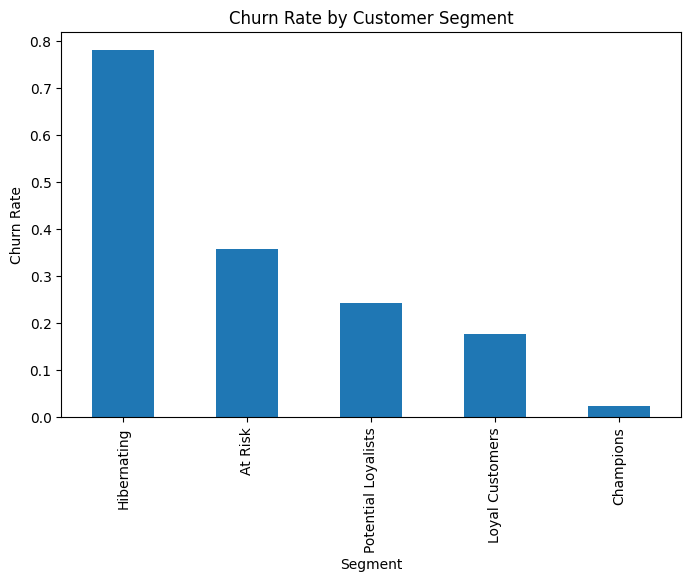

In [11]:
plt.figure(figsize=(8,5))

segment_churn.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title("Churn Rate by Customer Segment")
plt.ylabel("Churn Rate")
plt.xlabel("Segment")

plt.show()

In [13]:
behavior_summary = snapshot.groupby('segment')[
[
'return_rate_180d',
'ticket_count_90d',
'sessions_30d',
'campaign_clicks_30d',
'abandoned_carts_30d'
]
].mean()

behavior_summary

,return_rate_180d,ticket_count_90d,sessions_30d,campaign_clicks_30d,abandoned_carts_30d
segment,,,,,
At Risk,0.063422,0.220183,5.596330,0.761468,0.816514
Champions,0.071807,0.584795,8.122807,0.818713,0.994152
Hibernating,0.044907,0.075926,4.052778,0.604630,0.490741
Loyal Customers,0.087921,0.493902,6.567073,0.664634,0.865854
Potential Loyalists,0.074772,0.300228,6.450913,0.655251,0.780822


In [12]:
snapshot.to_csv(
    'customer_segments.csv',
    index=False
)

print("Customer segments saved successfully")

Customer segments saved successfully


In [14]:
segments = snapshot[
[
'customer_id',
'segment',
'recency_days',
'frequency_180d',
'monetary_180d',
'ticket_count_90d',
'return_rate_180d',
'campaign_clicks_30d',
'sessions_30d',
'churn_next_60d'
]
]

segments.to_csv(
'segments.csv',
index=False
)

segments.head()

,customer_id,segment,recency_days,frequency_180d,monetary_180d,ticket_count_90d,return_rate_180d,campaign_clicks_30d,sessions_30d,churn_next_60d
0,CUST00001,Hibernating,107,1,362.73,0,0.0,0,1,1
1,CUST00002,Potential Loyalists,40,1,581.00,1,0.0,0,8,0
2,CUST00003,Hibernating,171,1,649.98,0,0.0,0,1,1
3,CUST00004,Hibernating,131,1,1604.04,0,0.0,0,1,1
4,CUST00005,Loyal Customers,38,3,1781.90,0,0.0,1,18,0


In [16]:
manual_review = snapshot[
    (
        (snapshot['ticket_count_90d'] >= 2) &
        (snapshot['campaign_clicks_30d'] >= 3)
    )
].head(10)

manual_review[
[
'customer_id',
'recency_days',
'frequency_180d',
'monetary_180d',
'ticket_count_90d',
'campaign_clicks_30d',
'segment'
]
]

,customer_id,recency_days,frequency_180d,monetary_180d,ticket_count_90d,campaign_clicks_30d,segment
151,CUST00152,46,3,2730.26,3,3,Loyal Customers


In [17]:
manual_review = snapshot.sort_values(
    ['ticket_count_90d','campaign_clicks_30d'],
    ascending=False
).head(10)

manual_review[
[
'customer_id',
'recency_days',
'frequency_180d',
'monetary_180d',
'ticket_count_90d',
'campaign_clicks_30d',
'segment'
]
]

,customer_id,recency_days,frequency_180d,monetary_180d,ticket_count_90d,campaign_clicks_30d,segment
151,CUST00152,46,3,2730.26,3,3,Loyal Customers
1415,CUST01416,50,3,2785.86,3,2,Loyal Customers
1429,CUST01430,5,3,2362.84,3,0,Champions
41,CUST00042,87,5,4306.00,2,2,At Risk
178,CUST00179,38,3,1585.62,2,2,Loyal Customers
262,CUST00263,25,3,1618.39,2,2,Champions
437,CUST00438,64,3,2466.39,2,2,Loyal Customers
1426,CUST01427,5,4,2185.26,2,2,Champions
1525,CUST01526,9,2,2585.39,2,2,Potential Loyalists
1983,CUST01984,21,6,3972.70,2,2,Champions


In [18]:
segments = snapshot[
[
'customer_id',
'segment',
'recency_days',
'frequency_180d',
'monetary_180d',
'ticket_count_90d',
'return_rate_180d',
'campaign_clicks_30d',
'sessions_30d',
'churn_next_60d'
]
]

segments.to_csv(
'segments.csv',
index=False
)

print("segments.csv created")

segments.csv created
